In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score


In [9]:
df = pd.read_csv('/Users/parasgajam/Downloads/temperatures (1).csv')

In [5]:
df.shape

(117, 18)

In [6]:
df.isnull().sum()

YEAR       0
JAN        0
FEB        0
MAR        0
APR        0
MAY        0
JUN        0
JUL        0
AUG        0
SEP        0
OCT        0
NOV        0
DEC        0
ANNUAL     0
JAN-FEB    0
MAR-MAY    0
JUN-SEP    0
OCT-DEC    0
dtype: int64

In [12]:
import matplotlib.pyplot as plt
print(df.columns)

Index(['YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP',
       'OCT', 'NOV', 'DEC', 'ANNUAL', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP',
       'OCT-DEC'],
      dtype='str')


In [17]:
months = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN",
          "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]
monthly_temp = df[months].mean()
print(monthly_temp)

JAN    23.687436
FEB    25.597863
MAR    29.085983
APR    31.975812
MAY    33.565299
JUN    32.774274
JUL    31.035897
AUG    30.507692
SEP    30.486752
OCT    29.766581
NOV    27.285470
DEC    24.608291
dtype: float64


In [19]:
data_monthly = pd.DataFrame({
    "Month": range(1, 13),
    "Temperature": monthly_temp.values
})

print(data_monthly)

    Month  Temperature
0       1    23.687436
1       2    25.597863
2       3    29.085983
3       4    31.975812
4       5    33.565299
5       6    32.774274
6       7    31.035897
7       8    30.507692
8       9    30.486752
9      10    29.766581
10     11    27.285470
11     12    24.608291


In [20]:
X = data_monthly[['Month']]
y = data_monthly['Temperature']

In [21]:
model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.04]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Month']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,28.93
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [22]:
y_pred = model.predict(X)

print("Predicted temperatures:")
print(y_pred)

Predicted temperatures:
[28.97262108 29.01361953 29.05461797 29.09561642 29.13661487 29.17761331
 29.21861176 29.2596102  29.30060865 29.3416071  29.38260554 29.42360399]


In [23]:
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R-Square (R²):", r2)

Mean Squared Error (MSE): 9.5399406850022
Mean Absolute Error (MAE): 2.6022317188983872
R-Square (R²): 0.0020952362724367957


In [24]:
result = pd.DataFrame({
    "Month": range(1, 13),
    "Actual Temperature": y,
    "Predicted Temperature": y_pred
})

print(result)

    Month  Actual Temperature  Predicted Temperature
0       1           23.687436              28.972621
1       2           25.597863              29.013620
2       3           29.085983              29.054618
3       4           31.975812              29.095616
4       5           33.565299              29.136615
5       6           32.774274              29.177613
6       7           31.035897              29.218612
7       8           30.507692              29.259610
8       9           30.486752              29.300609
9      10           29.766581              29.341607
10     11           27.285470              29.382606
11     12           24.608291              29.423604


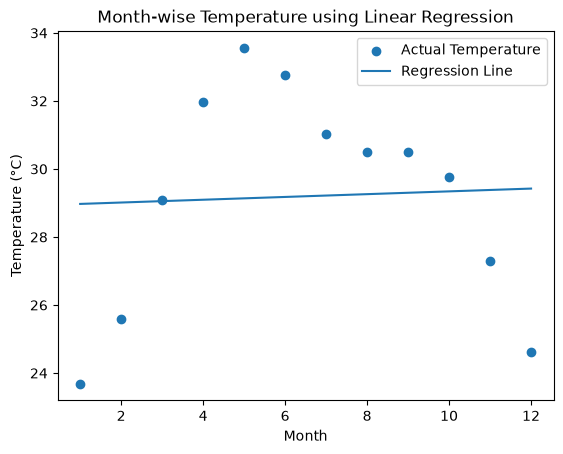

In [25]:
plt.scatter(X, y, label="Actual Temperature")

plt.plot(X, y_pred, label="Regression Line")

plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("Month-wise Temperature using Linear Regression")

plt.legend()
plt.show()